In [27]:
import numpy as np
from itertools import permutations
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina' # configures the figure format for high-resolution displays.
%matplotlib inline

Stochastic Block Model The Stochastic Block Model (SBM) is based on the following quantities:

1. The number of possible groups $q$;
2. The expected fraction of members of each group $\left\{n_{a}\right\}_{a=1}^{q}$, such that $\sum_{a=1}^{q} n_{a}=$ $1 ;$
3. The symmetric matrix $p_{a b} \in[0,1]^{q \times q}$ probability of an edge between group $a$ and $b$.

Given these elements, we can generate a directed graph $G$ with $N$ nodes and adjacency matrix $A$ as follows

1 Assign node $i$ to group $a$ with probability $P\left(g_{i}=a\right)=n_{a}$, where $g_{i}$ indicates the group assignment of node $i$. Repeat $\forall i \in 1, \ldots, N$.

2 Include an edge between nodes $i$ ad $j$ with probability $p_{g_{i}, g_{j}}$ setting $A_{i j}=$ 1 , and set $A_{i j}=0$ with probability $1-p_{g_{i}, g_{j}}$. Self-loops are forbidden, i.e. $A_{i i}=0$.

Question 1 ( 2 Pt.) Implement the function generate_data that takes as argument the parameters $N$ (number of nodes), $q$ (number of groups), $\left\{n_{a}\right\}_{a=1}^{q}$ (expected fraction of nodes per group, given as a list), and $p_{a b}$ (probability between two groups, given as a numpy matrix) and returns a $N$-dimensional vector $g$ (assignment of each node) and the adjacency matrix $A$ as defined above.

Question 2 (2 Pt.) Write explicitly the posterior distribution

$$
P\left(G,\left\{g_{i}\right\} \mid \theta\right) \propto P\left(G \mid\left\{g_{i}\right\}, \theta\right) P\left(\left\{g_{i}\right\} \mid \theta\right)
$$

where $\theta=\left\{q,\left\{n_{a}\right\},\left\{p_{a b}\right\}\right\}$ and show that the probability distribution over the group assignments can be written as:

$$
\mu\left(\left\{g_{i}\right\} \mid G, \theta\right)=P\left(\left\{g_{i}\right\} \mid G, \theta\right)=\frac{e^{-H\left(\left\{g_{i}\right\} \mid G, \theta\right)}}{\sum_{\left\{g_{i}\right\}} e^{-H\left(\left\{g_{i}\right\} \mid G, \theta\right)}}
$$

where

$$
H\left(\left\{g_{i}\right\} \mid G, \theta\right)=-\sum_{i} \log \left(n_{g_{i}}\right)-\sum_{i \neq j}\left[A_{i j} \log \left(p_{g_{i}, g_{j}}\right)+\left(1-A_{i j}\right) \log \left(1-p_{g_{i}, g_{j}}\right)\right]
$$


## Question 1 
Implement the function generate_data that takes as argument the parameters $N$ (number of nodes), $q$ (number of groups), $\left\{n_{a}\right\}_{a=1}^{q}$ (expected fraction of nodes per group, given as a list), and $p_{a b}$ (probability between two groups, given as a numpy matrix) and returns a $N$-dimensional vector $g$ (assignment of each node) and the adjacency matrix $A$ as defined above.


In [ ]:
def generate_data(N, q, na, pab): #q=number of possible groups 
    # Step 1: Assign nodes to groups
    g = np.random.choice(q, size=N, p=na) #we are using 0-based indexing here
        # na is a 1xq matrix where the ith entry is the frac of nodes in group i

    # Step 2: Generate adjacency matrix A
    A = np.zeros((N, N), dtype=int)
    for i in range(N):
        for j in range(i + 1, N): # i + 1 to avoid self loops
            # Assign edge between nodes i and j based on group probabilities
            edge_prob = pab[g[i] , g[j]] # Assuming 1-based indexing, convert to 0-based
            A[i, j] = np.random.choice([0, 1], p=[1 - edge_prob, edge_prob]) # Randomly pick either 0 or 1, with a specific probability for each
            A[j, i] = A[i, j]  # Graph is undirected, so set symmetric edge
            # Set diagonal entries to zero to forbid self-loops
    return g, A

## Question 3

- Write a function energy taking as input $\left\{g_{i}\right\},\left\{n_{a}\right\}_{a=1}^{q}, p_{a b}$ and $A$ and returning the value of the energy as in Eq. 3
- Implement a second function energy_difference, taking as input two node configurations $\left\{g_{i}^{\prime}\right\}$ and $\left\{g_{i}\right\}$ and the parameters $\left\{n_{a}\right\}_{a=1}^{q}, p_{a b}$ and $A$, and returning $H\left(\left\{g_{i}^{\prime}\right\} \mid G, \theta\right)-H\left(\left\{g_{i}\right\} \mid G, \theta\right)$

In [29]:
def energy(g, A, na, p):
    """
    Calculate the energy H({g_i}|G,θ).

    Parameters:
    - g: List of group assignments for nodes
    - A: Adjacency matrix
    - na: List of expected fractions of members of each group
    - p: Symmetric matrix representing the probability of an edge between groups

    Returns:
    - Energy H({g_i}|G,θ)
    """
    N = len(g)
    energy_value = 0

    # Term involving group fractions
    for i in range(N):
        energy_value -= np.log(na[g[i]])

    # Term involving adjacency matrix and edge probabilities
    for i in range(N):
        for j in range(N):
            if i != j:
                energy_value -= A[i, j] * np.log(p[g[i], g[j]]) + (1 - A[i, j]) * np.log(1 - p[g[i], g[j]])

    return energy_value


def energy_difference(g_prime, g, A, na, p):
    """
    Parameters:
    - g: first list of group assignments for nodes
    - g_prime: second list of group assignments for nodes
    - A: Adjacency matrix
    - na: List of expected fractions of members of each group
    - p: Symmetric matrix representing the probability of an edge between groups
    
    Returns:
    - Energy difference H({g_i'}|G,θ) - H({g_i}|G,θ)
    """
    energy_prime = energy(g_prime, A, na, p)
    energy_1 = energy(g, A, na, p)

    return energy_prime - energy_1

## Question 4
Consider :
- $N=100$;
- $q=2$;
- $n_{0}=0.7$ and $n_{1}=0.3$;
- $p_{01}=p_{10}=0.3, p_{00}=0.4, p_{11}=0.5$.

Sample a group assignment $\left\{g_{i}^{*}\right\}$ and an adjacency matrix $A$ from these parameters. Given $A$ and the parameters $\theta$, we would like to recover $g^{*}$ from a random initial configuration $\left\{g^{0}\right\}$. To do so, we resort to the Metropolis-Hastings scheme running for $T$ iterations:

- Initially, at $t=0$, sample $g^{0}$ where for each $g_{i}^{0}, P\left(g_{i}^{0}=1\right)=n_{1}$
- At each iteration $t$ : pick an index $i$ uniformly at random in $[0, N]$
- Define $\left\{g_{i}^{\prime}\right\}=\left\{g_{0}^{t}, \ldots, 1-g_{i}^{t}, \ldots, g_{N}^{t}\right\}$. Calculate the energy difference between $\left\{g_{i}^{\prime}\right\}$ and $\left\{g_{i}^{t}\right\}$, i.e., $\Delta H=$ energy_difference $\left(\left\{g_{i}^{\prime}\right\},\left\{g_{i}^{t}\right\},\left\{n_{a}\right\}_{a=1}^{q}, p_{a b}, A\right)$. With probability $\min (1, \exp (-\Delta H))$, set $\left\{g_{i}^{t+1}\right\}=\left\{g_{i}^{\prime}\right\}$, otherwise define $\left\{g_{i}^{t+1}\right\}=\left\{g_{i}^{t}\right\}$

Implement a function named run mcmc returning a sequence of $T$ states $\left\{g_{i}^{t}\right\}$ for $t=1, \ldots, T$.

In [30]:
def run_mcmc(N, q, na, pab, T):
    states = []
    # Initialize with a random configuration
    current_state = np.random.choice(q, size=N, p=na)

    for t in range(T):
        # Propose a new configuration
        proposed_state = current_state.copy()
        i = np.random.choice(N)
        # Flip the group assignment of a randomly chosen node
        proposed_state[i] = 1 - proposed_state[i]  
         

        # Calculate energy difference
        energy_diff = energy_difference(proposed_state, current_state, A, na, pab)

        # Accept or reject the proposed configuration
        if np.random.uniform() < min(1, np.exp(-energy_diff)):
            current_state = proposed_state

        states.append(current_state.copy())

        # Print time if it's a multiple of 500
        if t % 500 == 0:
            print(t)

    return states

## Question 5
For each of the $T$ states output by the run_mcmc function, compute

1. The state energy $H\left(g^{t}\right)$
2. The overlap between $g^{t}$ the ground truth state $g^{*}$. The overlap can be defined as $Q\left(\left\{g_{i}\right\},\left\{g_{i}^{*}\right\}\right)=\max _{\pi} \frac{\frac{1}{N} \sum_{i} \delta_{g_{i}^{*}, \pi\left(g_{i}\right)}-\max _{a} n_{a}}{1-\max _{a} n_{a}}$, where $\pi$ ranges over the permutations on $q$ elements.
3. The fraction of non-zero entries in $g^{t}$

Plot these quantities as a function of time.

In [31]:
# Function to compute overlap between two group assignments
def calculate_overlap(g_t, g_star, N, q, na):
    max_overlap = 0

    for perm in permutations(range(q)):
        perm_dict = {i: pi for i, pi in enumerate(perm)}
        overlap = (1 / N) * sum(g_star[i] == perm_dict[g_t[i]] for i in range(N))
        max_overlap = max(max_overlap, overlap)

    max_na = np.max(na)
    overlap_ratio = (max_overlap - max_na) / (1 - max_na)

    return overlap_ratio

    
def compute_quantities(states, A, N, q, na, pab, true_group):
    energies = []
    overlaps = []
    fractions_nonzero = []

    for state in states:
        # 1. Compute state energy
        energy_val = energy(state, A, na, pab)
        energies.append(energy_val)

        # 2. Compute overlap
        overlap_val = calculate_overlap(state, true_group, N, q, na)
        overlaps.append(overlap_val)

        # 3. Compute fraction of non-zero entries
        fraction_nonzero_val = np.sum(state != 0) / N
        fractions_nonzero.append(fraction_nonzero_val)

    return energies, overlaps, fractions_nonzero

In [ ]:
# Example usage:
N = 100
q = 2
na = np.array([0.7, 0.3])
pab = np.array([[0.4, 0.1], [0.1, 0.5]])
true_group, A = generate_data(N, q, na, pab)

T = 1000
mcmc_states = run_mcmc(N, q, na, pab, T)
energies, overlaps, fractions_nonzero = compute_quantities(mcmc_states, A, N, q, na, pab, true_group)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


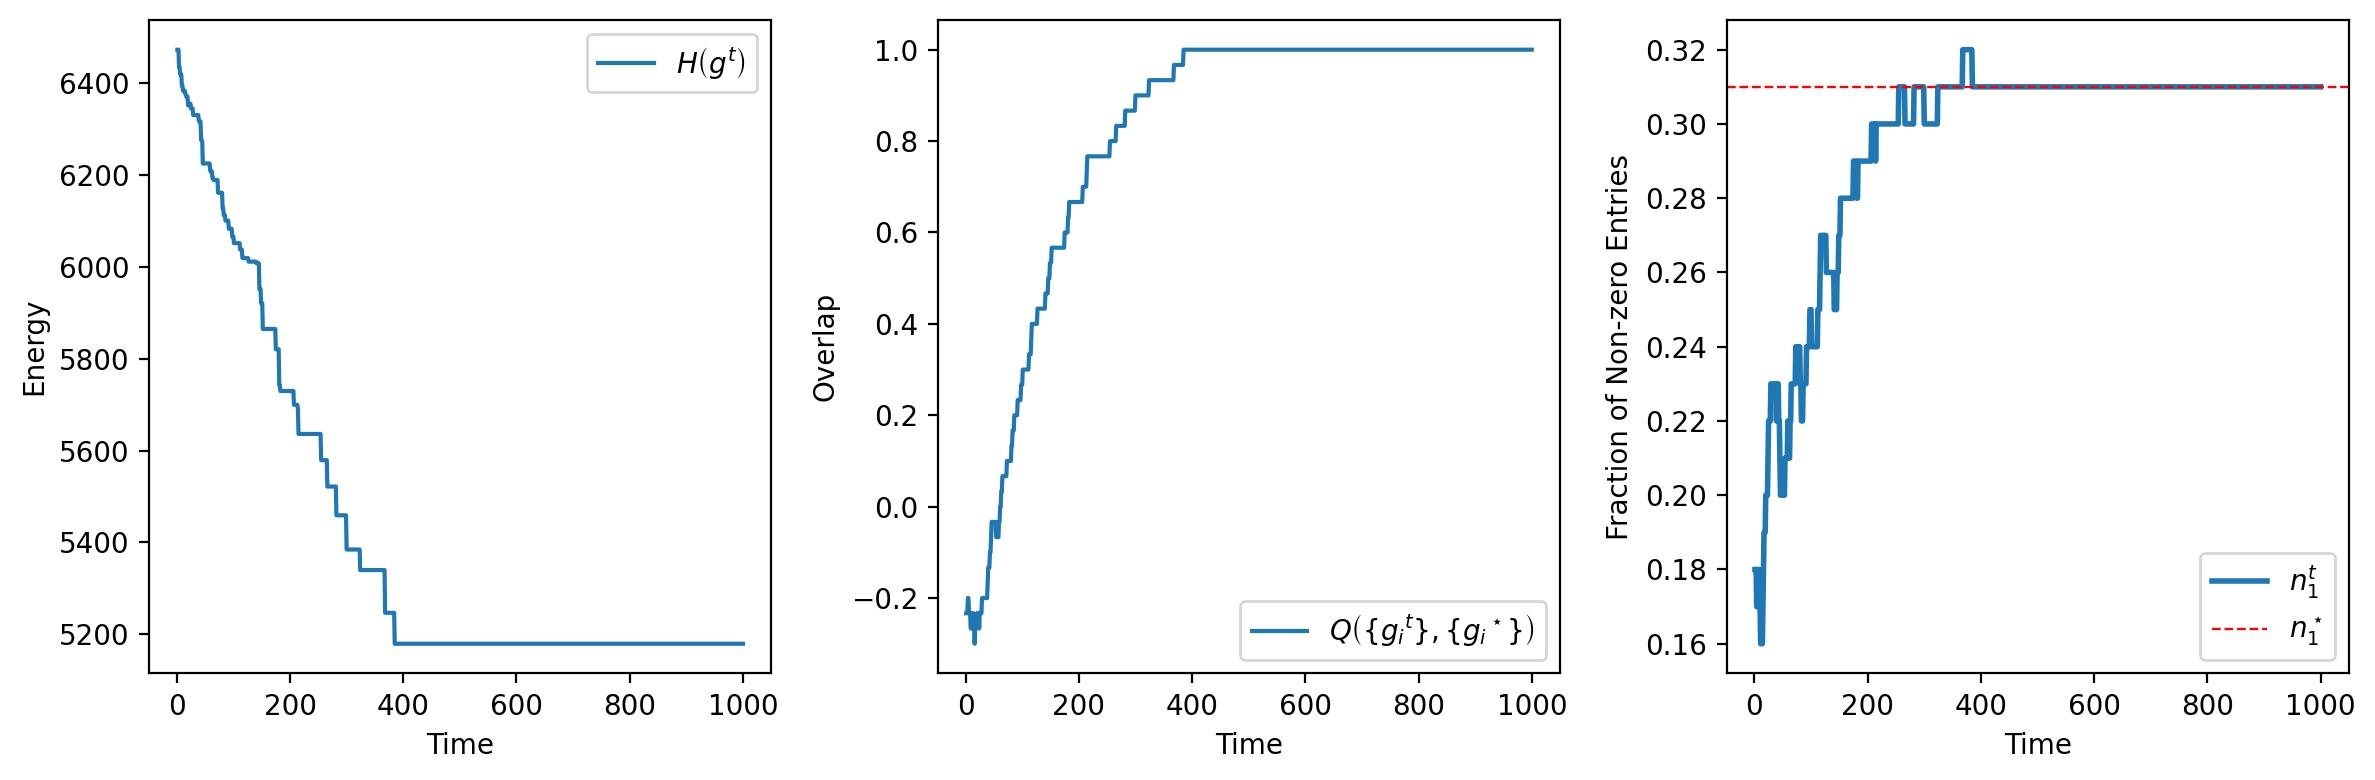

In [33]:


# Create time array
time = range(1, T + 1)

# Plot energies
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(time, energies, label=r'$H\left(g^t \right)$')
#plt.title('Energy vs Time')
plt.xlabel('Time')
plt.ylabel('Energy')
plt.legend()

# Plot overlaps
plt.subplot(1, 3, 2)
plt.plot(time, overlaps, label=r'$Q\left(\{{g_i}^t\}, \{{g_i}^\star\} \right)$')
#plt.title('Overlap vs Time')
plt.xlabel('Time')
plt.ylabel('Overlap')
plt.legend()

# Plot fractions_nonzero
plt.subplot(1, 3, 3)
plt.plot(time, fractions_nonzero, label=r'$n_1^t$', linewidth=2)
plt.axhline(y=np.sum(true_group != 0) / len(true_group), color='r', linestyle='--',linewidth=0.85, label=r'$n_1^\star$')
#plt.title('Fraction of Non-zero Entries vs Time')
plt.xlabel('Time')
plt.ylabel('Fraction of Non-zero Entries')
plt.legend()

plt.tight_layout()
plt.savefig('overlap.eps', format='eps')
plt.show()

## Question 6
We now consider the case where $p_{a b}, q$ and $A$ are available but the $\left\{n_{a}\right\}_{a=1}^{q}$ are not known and must be learnt. It can be shown that the maximization of the posterior distribution over the parameters $P(\theta \mid G)$ w.r.t. $n_{a}$ leads to the following update rule:

$$
\frac{1}{N} \sum_{i}\left\langle\delta_{g_{i}, a}\right\rangle=\frac{\left\langle N_{a}\right\rangle}{N}=n_{a} \quad \forall a=1, . ., q
$$

where by $\left\langle f\left(\left\{g_{i}\right\}\right)\right\rangle=\sum_{\left\{g_{i}\right\}} f\left(\left\{g_{i}\right\}\right) \mu\left(\left\{g_{i}\right\} \mid G, \theta\right)$ Given this update rule, use the Expectation-Maximization (EM) algorithm to infer $\left\{n_{a}\right\}_{a=1}^{q}$. Specifically, assume the ground-truth data are obtained under the setting specified in Question 4. Perform $M=10$ steps of EM, by using the run_mcmc function implemented before. Assume $n_{0}^{0}=0.55$ as your initial guess. Plot the evolution of $n_{0}^{m}$ as a function of the EM iterations (i.e., for $m=0, \ldots, M$ ).


In [ ]:
def expectation_step(states, q):
    N = len(states[0])
    expected_values = np.zeros((N, q))
    
    for state in states:
        for i in range(N):
            expected_values[i, state[i]] += 1
    
    return expected_values / len(states)  #divide by the number of samples
    """
    Instead of explicitly summing over all possible assignments, you can approximate this by using samples generated during the MCMC 
    (Markov Chain Monte Carlo) simulation. By counting the occurrences of different assignments across the generated samples, you obtain
    an empirical estimate of the expected values.
    This count is then used to estimate the expected values needed in the subsequent steps of the EM algorithm. It's a practical way to
    approximate the expected values without explicitly computing a summation over all possible assignments.
    Returns a Matrix where entry (i,q) is the expected value of node i belonging to group q across all T samples from the MCMC simulation
    """

def maximization_step(expected_values):
    return np.mean(expected_values, axis=0)
    """
    The function takes the matrix of expected values (expected_values) obtained from the E-step. Each row of this matrix 
    corresponds to a node, and each column corresponds to a possible group. The function calculates the mean along each column (axis=0).
    np.mean(expected_values, axis=0) --> 1xq vector
    Each element of the vector represents the mean (average) of the expected probabilities across all nodes for the corresponding group.
    """

def run_em(N, q, pab, M, initial_guess):
    # Initialize parameters
    na = initial_guess
    
    # Store the evolution of n_0^m
    evolution_n0 = []

    for m in range(1, M+1):
        print(f'm = {m} :')
        # E-step
        states = run_mcmc(N, q, na, pab, 5500)  # Run MCMC to generate samples
        expected_values = expectation_step(states, q)

        # M-step
        na = maximization_step(expected_values)
        
        # Store the evolution of n_0^m
        evolution_n0.append(na[0])
        print()

    return evolution_n0

# Ground truth parameters
N = 100
q = 2
pab_true = np.array([[0.4, 0.1], [0.1, 0.5]])

# Initial guess for n_0
initial_guess = np.array([0.55, 0.45])

# Number of EM steps
M = 10

# Run EM algorithm
evolution_n0 = run_em(N, q, pab_true, M, initial_guess)



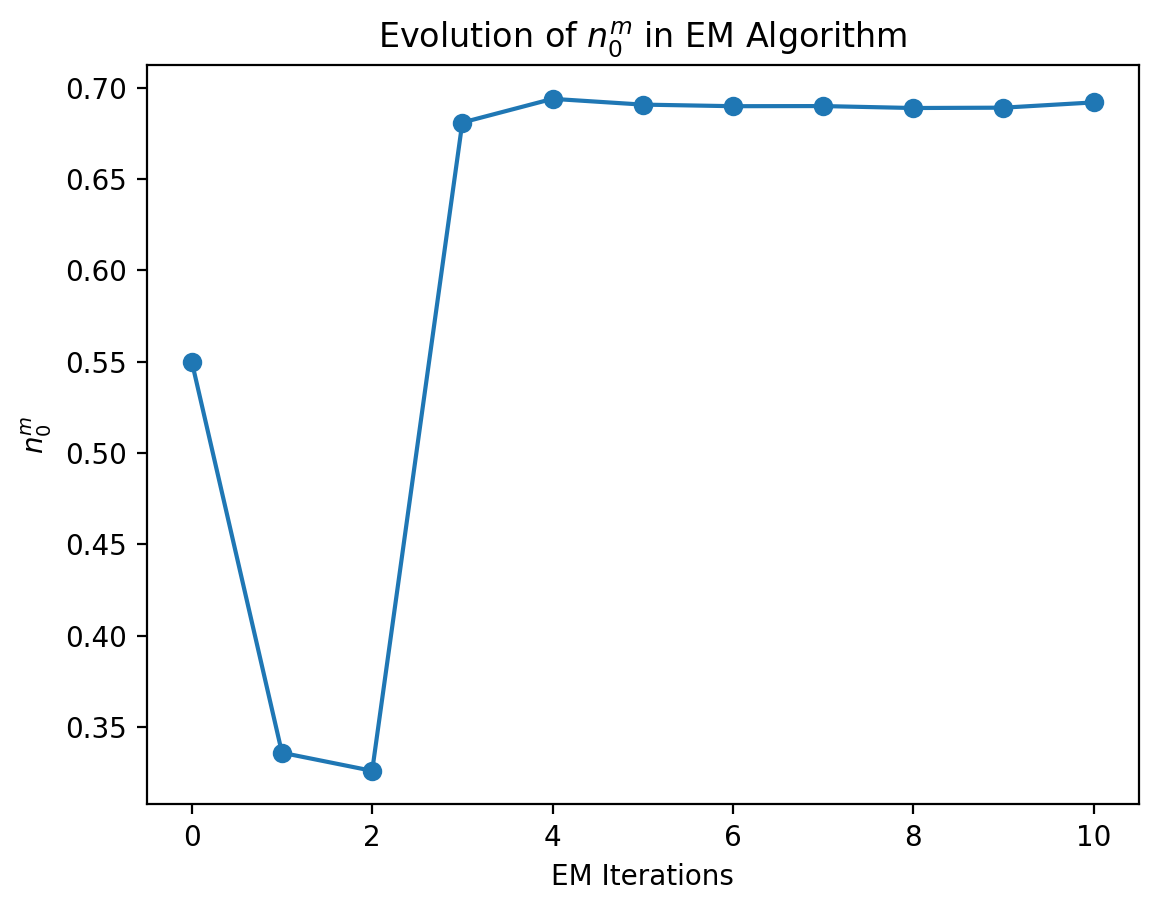

In [35]:
# Plot the evolution of n_0^m
plt.plot(np.concatenate([np.arange(M + 1)]), np.concatenate(([0.55], evolution_n0)), marker='o')
plt.xlabel('EM Iterations')
plt.ylabel(r'$n_0^m$')
plt.title(r'Evolution of $n_0^m$ in EM Algorithm')
plt.savefig('EM.eps', format='eps')
plt.show()


## Visualisation

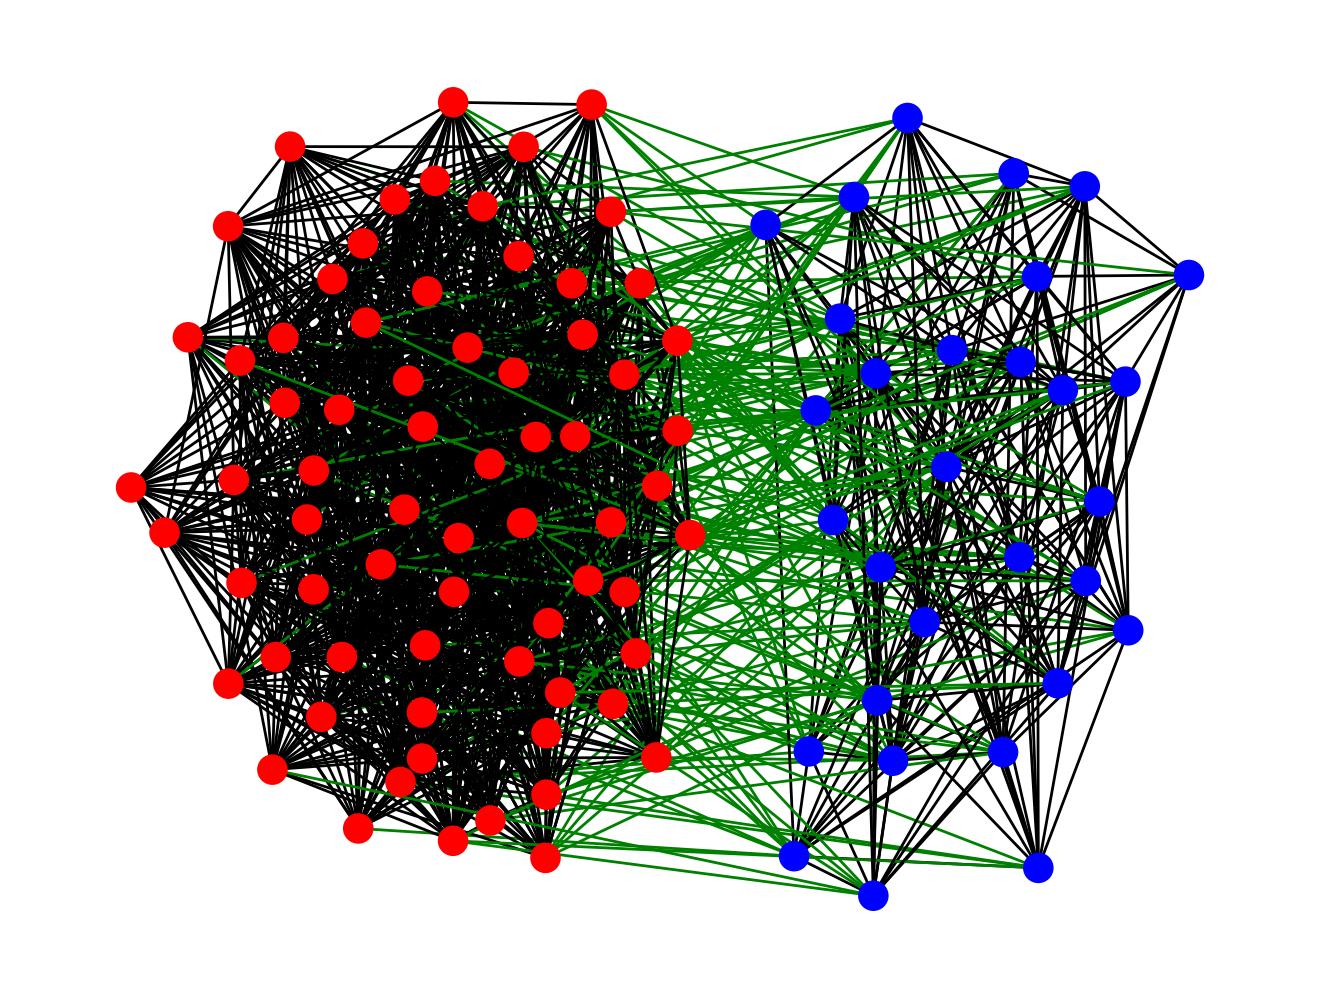

In [37]:
import networkx as nx

# Set seed for reproducibility
np.random.seed(42)

# Parameters
N = 100
q = 2
n = [0.7, 0.3]
p = np.array([[0.4, 0.1], [0.1, 0.5]])

# Generate graph
G = nx.Graph()

# Assign nodes to groups
node_groups = np.random.choice(q, N, p=n)
for i in range(N):
    G.add_node(i, group=node_groups[i])

# Generate edges
for i in range(N):
    for j in range(i + 1, N):
        if np.random.rand() < p[node_groups[i], node_groups[j]]:
            G.add_edge(i, j)

# Define node colors
colors = ['red' if G.nodes[i]['group'] == 0 else 'blue' for i in G.nodes]

# Define edge colors
edge_colors = ['black' if G.nodes[i]['group'] == G.nodes[j]['group'] else 'green' for i, j in G.edges]

# Draw the graph
pos = nx.spring_layout(G)  # You can use different layouts
nx.draw(G, pos, node_color=colors, edge_color=edge_colors, with_labels=False, font_weight='bold', node_size=100)

# Show the plot
plt.savefig('graph.eps', format='eps')
plt.show()
